# Loading Feature Engineered Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("train(1).xlsx")
print("Initial shape:", df.shape)
# Drop missing values
df = df.dropna()

# Remove non-positive prices
df = df[df["price"] > 0]

print("After cleaning:", df.shape)



Initial shape: (16209, 21)
After cleaning: (16209, 21)


In [2]:
df = df.drop(columns=["id",'zipcode'], errors="ignore")
df["date"] = pd.to_datetime(df["date"])

df["year_sold"] = df["date"].dt.year
df["month_sold"] = df["date"].dt.month

df = df.drop(columns=["date"])
df["renovated"] = (df["yr_renovated"] > 0).astype(int)

df["house_age"] = df["year_sold"] - df["yr_built"]
# log scale (VERY IMPORTANT)
df["log_sqft_living"] = np.log1p(df["sqft_living"])

# ratios
df["sqft_per_bed"] = df["sqft_living"] / (df["bedrooms"] + 1)
df["bath_per_bed"] = df["bathrooms"] / (df["bedrooms"] + 1)

# structure ratios
df["above_ratio"] = df["sqft_above"] / (df["sqft_living"] + 1)
lat_center = df["lat"].mean()
lon_center = df["long"].mean()

df["dist_center"] = np.sqrt(
    (df["lat"] - lat_center)**2 +
    (df["long"] - lon_center)**2
)



df["lat_long"] = df["lat"] * df["long"]
df["log_price"] = np.log(df["price"])
drop_cols = [
    "price",
    "sqft_above",
"sqft_living",
    "yr_built",
    "yr_renovated"
]

df = df.drop(columns=drop_cols)
df = df.reset_index(drop=True)
df["row_id"] = df.index
df.shape

(16209, 25)

In [3]:
df.columns


Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'year_sold', 'month_sold', 'renovated', 'house_age',
       'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
       'dist_center', 'lat_long', 'log_price', 'row_id'],
      dtype='object')

In [4]:
# ===============================
# IMPORTS
# ===============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

# ===============================
# FEATURES & TARGET
# ===============================
X = df.drop(columns=["log_price","row_id"])
y = df["log_price"].values

# ===============================
# SPLIT: TRAIN / VAL / TEST
# ===============================
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y,
    test_size=0.25,      # 70% train
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,      # 15% val, 15% test
    random_state=42
)

# ===============================
# SCALING
# ===============================
scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




In [5]:
# ===============================
# IMPORTS
# ===============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

# ===============================
# TABULAR FEATURE LIST (LOCKED)
# ===============================
tabular_cols = [
    'bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
    'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
    'sqft_lot15', 'year_sold', 'month_sold', 'renovated', 'house_age',
    'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
    'dist_center',
    'lat_long'
]


# ===============================
# PREPARE TABULAR DATA
# ===============================
df_tab = df.copy()
df_tab = df_tab.reset_index(drop=True)
df_tab["row_id"] = df_tab.index
df_tab = df_tab[tabular_cols+['log_price' ,'row_id']]

# ===============================
# LOAD IMAGE EMBEDDINGS
# ===============================
X_img = np.load("cnn_embeddings.npy")
img_map = pd.read_csv("cnn_embedding_index.csv")

img_df = pd.DataFrame(X_img)
img_df["row_id"] = img_map["row_id"]

# ===============================
# MERGE (SAFE MAPPING)
# ===============================
df_fused = df_tab.merge(img_df, on="row_id", how="inner")
print("Rows after merge:", df_fused.shape[0])

# ===============================
# FEATURES & TARGET
# ===============================
y = df_fused["log_price"].values
X_tab = df_fused[tabular_cols].values
X_img = df_fused.iloc[:, -X_img.shape[1]:].values

# ===============================
# SCALE + PCA
# ===============================
scaler = StandardScaler()
X_tab_scaled = scaler.fit_transform(X_tab)

pca = PCA(n_components=512, random_state=42)
X_img_reduced = pca.fit_transform(X_img)

X_img_tr, X_img_temp, _, _ = train_test_split(
    X_img_reduced, y,
    test_size=0.25,
    random_state=42
)

X_img_val, X_img_test, _, _ = train_test_split(
    X_img_temp, y_temp ,
    test_size=0.5,
    random_state=42
)



Rows after merge: 16209


In [6]:
# ===============================
# IMPORTS
# ===============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

# ===============================
# FEATURES & TARGET
# ===============================
X = df.drop(columns=["log_price","row_id"])
y = df["log_price"].values

# ===============================
# SPLIT: TRAIN / VAL / TEST
# ===============================
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y,
    test_size=0.25,      # 70% train
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,      # 15% val, 15% test
    random_state=42
)

# ===============================
# SCALING
# ===============================
scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




# Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ===============================
# MODEL
# ===============================
lr = LinearRegression(
    n_jobs=-1
)

# ===============================
# TRAIN
# ===============================
lr.fit(X_tr_scaled, y_tr)

# ===============================
# PREDICTIONS
# ===============================
y_tr_pred = lr.predict(X_tr_scaled)
y_val_pred = lr.predict(X_val_scaled)
y_test_pred = lr.predict(X_test_scaled)

# ===============================
# METRICS
# ===============================
def evaluate(y_true, y_pred):
    return (
        r2_score(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred))
    )

r2_tr, rmse_tr = evaluate(y_tr, y_tr_pred)
r2_val, rmse_val = evaluate(y_val, y_val_pred)
r2_test, rmse_test = evaluate(y_test, y_test_pred)

# ===============================
# RESULTS
# ===============================
print("\nLinear Regression Results (Tabluar)")
print("--------------------------------")
print(f"Train → R²: {r2_tr:.4f} | RMSE: {rmse_tr:.4f}")
print(f"Val   → R²: {r2_val:.4f} | RMSE: {rmse_val:.4f}")
print(f"Test  → R²: {r2_test:.4f} | RMSE: {rmse_test:.4f}")

print("\nOverfitting Check")
print("------------------")
print(f"Train–Val R² gap : {r2_tr - r2_val:.4f}")
print(f"Train–Test R² gap: {r2_tr - r2_test:.4f}")



Linear Regression Results (Tabluar)
--------------------------------
Train → R²: 0.7840 | RMSE: 0.2435
Val   → R²: 0.7837 | RMSE: 0.2394
Test  → R²: 0.7855 | RMSE: 0.2465

Overfitting Check
------------------
Train–Val R² gap : 0.0002
Train–Test R² gap: -0.0015


# Xgboost (Tabular)

In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ===============================
# MODEL (REGULARIZED)
# ===============================
xgb = XGBRegressor(
    n_estimators=850,        # slightly more trees but controlled
    max_depth=4,             # ↓ tree depth (KEY)
    learning_rate=0.05,
    min_child_weight=10,     # avoids noisy splits
    subsample=0.7,           # randomness
    colsample_bytree=0.7,
    reg_alpha=0.5,           # L1 regularization
    reg_lambda=2.0,          # L2 regularization
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ===============================
# TRAIN
# ===============================
xgb.fit(X_tr_scaled, y_tr)

# ===============================
# PREDICTIONS
# ===============================
y_tr_pred = xgb.predict(X_tr_scaled)
y_val_pred = xgb.predict(X_val_scaled)
y_test_pred = xgb.predict(X_test_scaled)

# ===============================
# METRICS
# ===============================
def evaluate(y_true, y_pred):
    return (
        r2_score(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred))
    )

r2_tr, rmse_tr = evaluate(y_tr, y_tr_pred)
r2_val, rmse_val = evaluate(y_val, y_val_pred)
r2_test, rmse_test = evaluate(y_test, y_test_pred)

# ===============================
# RESULTS
# ===============================
print("\nXGBoost Results (Regularized)")
print("--------------------------------")
print(f"Train → R²: {r2_tr:.4f} | RMSE: {rmse_tr:.4f}")
print(f"Val   → R²: {r2_val:.4f} | RMSE: {rmse_val:.4f}")
print(f"Test  → R²: {r2_test:.4f} | RMSE: {rmse_test:.4f}")

print("\nOverfitting Check")
print("------------------")
print(f"Train–Val R² gap : {r2_tr - r2_val:.4f}")
print(f"Train–Test R² gap: {r2_tr - r2_test:.4f}")



XGBoost Results (Regularized)
--------------------------------
Train → R²: 0.9413 | RMSE: 0.1269
Val   → R²: 0.8985 | RMSE: 0.1640
Test  → R²: 0.9084 | RMSE: 0.1611

Overfitting Check
------------------
Train–Val R² gap : 0.0428
Train–Test R² gap: 0.0329


# Xgboost ( Tabular + Image residual Model )

In [9]:
residual_tr = y_tr - y_tr_pred
residual_val = y_val - y_val_pred
residual_test = y_test - y_test_pred


In [10]:
xgb_img_res = XGBRegressor(
    n_estimators=350,        # slightly more trees
    max_depth=3,             # shallower trees (KEY)
    learning_rate=0.05,
    min_child_weight=10,     # avoid noisy splits
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,           # L1 regularization
    reg_lambda=2.0,          # L2 regularization
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_img_res.fit(
    X_img_tr,
    residual_tr,
    eval_set=[(X_img_val, residual_val)],
    verbose=50
)


[0]	validation_0-rmse:0.16392
[50]	validation_0-rmse:0.16360
[100]	validation_0-rmse:0.16337
[150]	validation_0-rmse:0.16337
[200]	validation_0-rmse:0.16339
[250]	validation_0-rmse:0.16351
[300]	validation_0-rmse:0.16360
[349]	validation_0-rmse:0.16360


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=350,
             n_jobs=-1, num_parallel_tree=None, ...)

In [11]:
res_tr_pred = xgb_img_res.predict(X_img_tr)
res_val_pred = xgb_img_res.predict(X_img_val)
res_test_pred = xgb_img_res.predict(X_img_test)


In [12]:
y_tr_final = y_tr_pred + res_tr_pred
y_val_final = y_val_pred + res_val_pred
y_test_final = y_test_pred + res_test_pred


In [13]:
def regression_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → R²: {r2:.4f} | RMSE: {rmse:.4f}")

regression_metrics(y_tr, y_tr_final, "Train")
regression_metrics(y_val, y_val_final, "Val")
regression_metrics(y_test, y_test_final, "Test")


Train → R²: 0.9539 | RMSE: 0.1124
Val → R²: 0.8990 | RMSE: 0.1636
Test → R²: 0.9096 | RMSE: 0.1600


# ANN (Tabular)


In [14]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [15]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# ===============================
# MODEL
# ===============================
class FeatureNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeatureNet(X_tr_scaled.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# ===============================
# DATA
# ===============================
X_tr = torch.tensor(X_tr_scaled, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_tr = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# ===============================
# TRAIN
# ===============================
EPOCHS = 300
BATCH_SIZE = 256

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_tr.size(0))
    epoch_loss = 0

    for i in range(0, X_tr.size(0), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb, yb = X_tr[idx], y_tr[idx]

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

# ===============================
# PREDICTIONS
# ===============================
model.eval()
with torch.no_grad():
    y_tr_pred = model(X_tr).cpu().numpy()
    y_val_pred = model(X_val).cpu().numpy()
    y_test_pred = model(X_test).cpu().numpy()

# ===============================
# METRICS
# ===============================
def evaluate(y_true, y_pred):
    return (
        r2_score(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred))
    )

r2_tr, rmse_tr = evaluate(y_tr.cpu(), y_tr_pred)
r2_val, rmse_val = evaluate(y_val.cpu(), y_val_pred)
r2_test, rmse_test = evaluate(y_test.cpu(), y_test_pred)

# ===============================
# RESULTS
# ===============================
print("\nNeural Network Results(Tabular)")
print("--------------------------------")
print(f"Train → R²: {r2_tr:.4f} | RMSE: {rmse_tr:.4f}")
print(f"Val   → R²: {r2_val:.4f} | RMSE: {rmse_val:.4f}")
print(f"Test  → R²: {r2_test:.4f} | RMSE: {rmse_test:.4f}")

print("\nOverfitting Check")
print("------------------")
print(f"Train–Val R² gap : {r2_tr - r2_val:.4f}")
print(f"Train–Test R² gap: {r2_tr - r2_test:.4f}")



Neural Network Results(Tabular)
--------------------------------
Train → R²: 0.8939 | RMSE: 0.1707
Val   → R²: 0.8714 | RMSE: 0.1846
Test  → R²: 0.8798 | RMSE: 0.1845

Overfitting Check
------------------
Train–Val R² gap : 0.0225
Train–Test R² gap: 0.0142


# Grad-CAM (Model Explainability)


Selected row_ids: [7415, 10180, 3470, 16165, 5083]


/opt/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


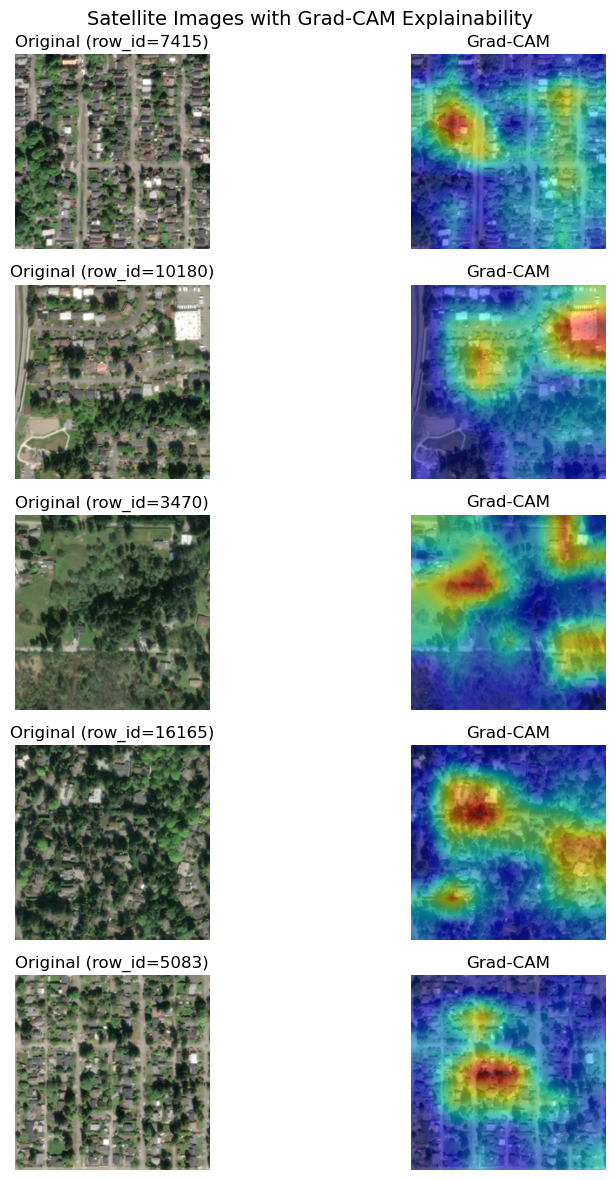

In [16]:
import zipfile
import random
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from torchvision import models, transforms

# ===============================
# CONFIG
# ===============================
zip_path = "sat_images_esri.zip"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# LOAD RANDOM 5 ROW_IDS
# ===============================
with zipfile.ZipFile(zip_path, "r") as z:
    all_row_ids = [
        int(name.split("/")[-1].replace(".png", ""))
        for name in z.namelist()
        if name.startswith("sat_images_esri/")
        and name.endswith(".png")
        and "__MACOSX" not in name
    ]

row_ids = random.sample(all_row_ids, 5)
print("Selected row_ids:", row_ids)

# ===============================
# LOAD CNN
# ===============================
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = model.to(device)
model.eval()
target_layer = model.layer4[-1]

# ===============================
# GRAD-CAM CLASS
# ===============================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x):
        out = self.model(x)
        score = out[:, out.argmax(dim=1)]
        self.model.zero_grad()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()
        return cam.detach().cpu().numpy()[0]

gradcam = GradCAM(model, target_layer)

# ===============================
# PREPROCESS
# ===============================
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# DISPLAY IMAGES + GRAD-CAM
# ===============================
plt.figure(figsize=(10, 12))

for i, row_id in enumerate(row_ids):
    with zipfile.ZipFile(zip_path, "r") as z:
        img_path = f"sat_images_esri/{row_id}.png"
        img_bytes = z.read(img_path)
        img = Image.open(BytesIO(img_bytes)).convert("RGB")

    input_tensor = preprocess(img).unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor)
    cam = cv2.resize(cam, img.size)

    # Original image
    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Original (row_id={row_id})")
    plt.axis("off")

    # Grad-CAM overlay
    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(img)
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.suptitle("Satellite Images with Grad-CAM Explainability", fontsize=14)
plt.tight_layout()
plt.show()


# TEST PRICE PREDICTION

In [17]:
import pandas as pd
import numpy as np



df_test = pd.read_excel("test2.xlsx")
print("Initial test shape:", df_test.shape)

df_test = df_test.dropna()


df_test = df_test.drop(columns=["id",'zipcode'], errors="ignore")

df_test["date"] = pd.to_datetime(df_test["date"])
df_test["year_sold"] = df_test["date"].dt.year
df_test["month_sold"] = df_test["date"].dt.month
df_test = df_test.drop(columns=["date"])

df_test["renovated"] = (df_test["yr_renovated"] > 0).astype(int)
df_test["house_age"] = df_test["year_sold"] - df_test["yr_built"]

df_test["log_sqft_living"] = np.log1p(df_test["sqft_living"])

df_test["sqft_per_bed"] = df_test["sqft_living"] / (df_test["bedrooms"] + 1)
df_test["bath_per_bed"] = df_test["bathrooms"] / (df_test["bedrooms"] + 1)

df_test["above_ratio"] = df_test["sqft_above"] / (df_test["sqft_living"] + 1)

# IMPORTANT: use TRAIN center, not test
df_test["dist_center"] = np.sqrt(
    (df_test["lat"] - lat_center)**2 +
    (df_test["long"] - lon_center)**2
)


df_test["lat_long"] = df_test["lat"] * df_test["long"]
df_test = df_test.drop(columns=[
     "sqft_living", "sqft_above",
    "yr_built", "yr_renovated"
])


df_test = df_test.reset_index(drop=True)
df_test["row_id"] = df_test.index


df_test.shape
df_test.columns

Initial test shape: (5404, 20)


Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'year_sold', 'month_sold', 'renovated', 'house_age',
       'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
       'dist_center', 'lat_long', 'row_id'],
      dtype='object')

In [18]:
df_test.shape

(5404, 24)

In [19]:
df_test.columns

Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'year_sold', 'month_sold', 'renovated', 'house_age',
       'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
       'dist_center', 'lat_long', 'row_id'],
      dtype='object')

In [20]:
df.shape

(16209, 25)

In [21]:
df.columns

Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'year_sold', 'month_sold', 'renovated', 'house_age',
       'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
       'dist_center', 'lat_long', 'log_price', 'row_id'],
      dtype='object')

In [22]:
df_tab_test = df_test.copy()
df_tab_test = df_tab_test.reset_index(drop=True)
df_tab_test["row_id"] = df_tab_test.index

df_tab_test = df_tab_test[tabular_cols+['row_id']]


In [23]:
X_img_test = np.load("cnn_test_embeddings.npy")
img_map_test = pd.read_csv("cnn_test_embedding_index.csv")

img_df_test = pd.DataFrame(X_img_test)
img_df_test["row_id"] = img_map_test["row_id"]


In [24]:
df_fused_test = df_tab_test.merge(
    img_df_test,
    on="row_id",
    how="inner"
)

print("Test rows after merge:", df_fused_test.shape[0])


Test rows after merge: 5404


In [25]:
X_tab_test = df_fused_test[tabular_cols].values
X_img_test = df_fused_test.iloc[:, -X_img_test.shape[1]:].values

In [26]:
X_img_test.shape

(5404, 2048)

In [27]:
X_tab_test_scaled = scaler.transform(X_tab_test)
X_img_test_reduced = pca.transform(X_img_test)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
# Tabular-only
y_test_tab = xgb.predict(X_tab_test_scaled)

# Residual image
residual_test_pred = xgb_img_res.predict(X_img_test_reduced)

# Final prediction (log-price)
y_test_log_final = y_test_tab + residual_test_pred

# Convert to price
y_test_price_pred = np.exp(y_test_log_final)


In [29]:
prediction_file=pd.read_excel("test2.xlsx")

In [30]:
prediction_file["predicted_price"] = y_test_price_pred


In [32]:
prediction_file[["id", "predicted_price"]].to_csv(
    "price_predictions.csv",
    index=False
)
